# Temporal Topic Modelling with Temporal Mapper and Toponymy
In this notebook, we will go though an example of how to use [Temporal Mapper](https://github.com/TutteInstitute/temporal-mapper) and 
[Toponymy](https://github.com/TutteInstitute/toponymy) together to create a temporal topic model of a corpus of documents. Be warned that this is an experimental, evolving workflow, so what you're about to see is not pretty.

The dataset we will use is the [United Nations General Debate Corpus](https://www.kaggle.com/datasets/unitednations/un-general-debates)
which consists of transcripts of the United Nations general debate from 1970 to 2015. I've preprocessed the dataset by chunking the speeches
and then embedding the chunks with a sentence-transformer and reducing them to 2D using UMAP. Let's fetch the dataset from the HuggingFace Hub: 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ungdc_df = pd.read_parquet("https://huggingface.co/datasets/kalebr/un-general-debate-corpus-chunked/resolve/main/ungdc-all-chunked.pq")
ungdc_df.head()

,session,year,country,text,chunk,information_weight,embedding,reduced
0,44,1989,MDV,﻿It is indeed a pleasure for me and the member...,﻿It is indeed a pleasure for me and the member...,29.816833,"[-0.009967008, 0.028972907, 0.014457686, 0.022...","[9.491389, 7.566777]"
0,44,1989,MDV,﻿It is indeed a pleasure for me and the member...,"Developments in southern Africa, and more part...",23.011437,"[0.050711717, 0.09013895, 0.0096756825, -0.016...","[6.820655, 4.6092267]"
0,44,1989,MDV,﻿It is indeed a pleasure for me and the member...,Positive strides have been taken towards the s...,21.294486,"[0.07367871, 0.045660958, 0.020714706, -0.0277...","[1.6624191, 2.9213235]"
0,44,1989,MDV,﻿It is indeed a pleasure for me and the member...,The process of reunification of peoples should...,21.153001,"[0.057730194, 0.083791696, 0.012951973, -0.019...","[-0.5313732, 0.14173953]"
1,44,1989,FIN,"﻿\nMay I begin by congratulating you. Sir, on ...",In the process of preparing both the developme...,25.820817,"[-0.012931386, -0.017169893, 0.012649347, -0.0...","[3.1583965, 11.189846]"


The *information weight* column is an importance metric similar to TF-IDF that I computed using [InformationWeightTransform](https://vectorizers.readthedocs.io/en/latest/information_weight_transform.html). Let's filter the dataset by taking the top 50% of informative chunks - this is just to get a somewhat more manageable size of dataset.

In [2]:
q = 50
cutoff = np.percentile(ungdc_df['information_weight'].values, q)
top_weighted = ungdc_df[ungdc_df['information_weight']>=cutoff]

embedding = np.stack(top_weighted['embedding'].values)
reduced = np.stack(top_weighted['reduced'].values)
time = top_weighted['year'].to_numpy()
text = top_weighted['chunk'].to_numpy()
print(len(top_weighted))

18654


### Toponymy Parameters
Next, we set up our Toponymy parameters:

In [3]:

from toponymy.toponymy import Toponymy, ToponymyClusterer, KeyphraseBuilder, ClusterLayerText
from toponymy.llm_wrappers import AzureAINamer

from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer("paraphrase-MiniLM-L3-v2")

api_key_file = 'cohere.txt'
with open(api_key_file, 'r') as file:
    azure_api_key = file.read().strip()
llm_wrapper=AzureAINamer(
    azure_api_key,
    endpoint="https://azureaitimcuse5821437469.services.ai.azure.com/models",
    model="Cohere-command-r-08-2024",
)


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L3-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### MapperClusterer class for Toponymy

In the next two cells, I create a `MapperClusterer` class that inherents Toponymy's `Clusterer` class. This will be the clusterer that we pass to Toponymy to create our Topic Model.  

The MapperClusterer takes another (non-temporal) Toponymy Clusterer object as a parameter. Then what it does is initialize a `TemporalMapper` and use it to compute temporal density and slice the dataset as per usual for Mapper. However, instead of clustering and creating a graph, we run the Toponymy Clusterer at each time slice, generating a tree of clusters of each time step.

For each layer `l` of the cluster hierarchy, we duplicate the initial `TemporalMapper` object and then assign the layer-`l` clusters to it, and complete the TemporalMapper algorithm. This means we have a Mapper graph for each layer `l` of the Toponymy clusters. We use the `TemporalMapper.assign_topics()` method to define an equivalence class on the nodes of the cluster trees across time slices, and identify the cluster trees into one big tree using this equivalence class. This big cluster tree is then the output of `MapperClusterer`.

Right now (as of 2026-03-12) the MapperClusterer class is ad-hoc and not robust to many things that can go wrong. However it is my goal to get the class to a useable state and contribute it to the Toponymy package for ready availability.

In [4]:
import networkx as nx
from collections import defaultdict, deque

class UnionFind:
    def __init__(self):
        self.parent = {}
        self.rank = {}

    def add(self, x):
        if x not in self.parent:
            self.parent[x] = x
            self.rank[x] = 0

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return
        if self.rank[rx] < self.rank[ry]:
            self.parent[rx] = ry
        else:
            self.parent[ry] = rx
            if self.rank[rx] == self.rank[ry]:
                self.rank[rx] += 1


def convert(node, layer):
    t,c = node.split(":")
    return (layer, int(c))

def merge_trees(topic_trees, graphs):
    """
    graphs[0] = leaves
    graphs[-1] = nodes just below root
    Parent of node in layer l is in layer l+1.

    Returns:
        {
            layer: {
                node: equivalence_class_id
            }
        }
    """

    # ---------------------------------------------
    # Build parent lookup from topic_trees
    # ---------------------------------------------
    parent_lookup = []

    for tree in topic_trees:
        parent = {}
        for p, children in tree.items():
            for c in children:
                parent[c] = p

        # roots get parent None
        for node in tree:
            if node not in parent:
                parent[node] = None

        parent_lookup.append(parent)

    n_layers = len(graphs)
    result = {}

    # ---------------------------------------------
    # Process layers top-down
    # ---------------------------------------------
    for l in reversed(range(n_layers)):
        G = graphs[l]
        uf = UnionFind()

        topics = nx.get_node_attributes(G, "topic")
        slice_no = nx.get_node_attributes(G, "slice_no")

        nodes = list(G.nodes())

        for node in nodes:
            uf.add(node)

        groups = defaultdict(list)

        for node in nodes:
            tree_index = slice_no[node]
            parent_node = parent_lookup[tree_index][convert(node,l)]

            # Determine parent equivalence class
            if parent_node == (n_layers, 0):
                parent_class = None
            else:
                _,pc = parent_node
                parent_class = result[l + 1][f'{tree_index}:{pc}']

            key = (topics[node], parent_class)
            groups[key].append(node)

        # Merge nodes within each structural group
        for group_nodes in groups.values():
            base = group_nodes[0]
            for other in group_nodes[1:]:
                uf.union(base, other)

        # Assign final class IDs for this layer
        rep_to_class = {}
        class_counter = 0
        layer_map = {}

        for node in nodes:
            rep = uf.find(node)
            if rep not in rep_to_class:
                rep_to_class[rep] = class_counter
                class_counter += 1
            layer_map[node] = rep_to_class[rep]
        # add the noise point possibilities
        for t in range(len(topic_trees)):
            layer_map[f'{t}:{-1}'] = -1

        result[l] = layer_map

    return result

In [2]:

from toponymy.clustering import Clusterer, build_cluster_tree, centroids_from_labels
from temporalmapper import TemporalMapper
from toponymy._utils import handle_verbose_params
from copy import deepcopy 
import networkx as nx
import numpy as np
from scipy.sparse import issparse
from sklearn.utils.validation import check_is_fitted, check_array
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
class MapperClusterer(Clusterer):
    def __init__(
        self,
        base_clusterer: Clusterer,
        mapper_params: dict | None = None,
        verbose: bool = None,
        show_progress_bar: bool = None,
    ):
        self.base_clusterer = base_clusterer
        if mapper_params is None:
            mapper_params = {}
        self.mapper_params = mapper_params
        
        super().__init__()
        _, self.verbose = handle_verbose_params(
            verbose=verbose, show_progress_bar=show_progress_bar, default_verbose=False
        )

    def fit(
        self,
        clusterable_vectors: np.ndarray,
        embedding_vectors: np.ndarray,
        projection_index: int = -1,
        layer_class = ClusterLayerText,
        verbose: bool = None,
        show_progress_bar: bool = None,
        **layer_kwargs,
    ) -> Clusterer:
        _, verbose_output = handle_verbose_params(
            verbose=verbose if verbose is not None else self.verbose,
            show_progress_bar=show_progress_bar,
            default_verbose=False,
        )
        base_mapper = TemporalMapper(
            clusterer = None,
            **self.mapper_params,
        )
        lens = clusterable_vectors[:, projection_index]
        data = np.delete(
            clusterable_vectors,
            projection_index,
            axis=1
        )
        if issparse(clusterable_vectors):
            base_mapper._mapper.scaler_ = StandardScaler(copy=False, with_mean=False)
        else:
            base_mapper._mapper.scaler_ = StandardScaler(copy=False)
        base_mapper._mapper._compute_midpoints(lens)
        base_mapper._mapper._compute_density(data, lens)
        base_mapper._mapper._compute_weights(data, lens)
        n_layers = 0
        topic_trees = []
        graphs = []
        mappers = []
        slicewise_layers = []
        n_slices = len(base_mapper._mapper.slices_)
        for i, slice_ in enumerate(base_mapper._mapper.slices_):
            cvectors = data[slice_]
            evectors = embedding_vectors[slice_]    
            cluster_layers, cluster_tree  = self.base_clusterer.fit_predict(
                clusterable_vectors = cvectors,
                embedding_vectors = evectors,
                layer_class=layer_class,
                verbose=verbose,
                show_progress_bar=show_progress_bar,
                **layer_kwargs,
            )
            if len(cluster_layers)>n_layers:
                n_layers = len(cluster_layers)
            topic_trees.append(cluster_tree)
            slicewise_layers.append(cluster_layers)
        print(f"Layers per slice: {[len(x) for x in slicewise_layers]}")
        for l in range(n_layers):
            sizes = []
            for clayers in slicewise_layers:
                n_clusters = np.unique(clayers[l].cluster_labels).size
                sizes.append(n_clusters)
            print(f"Layer {l} n_cluster: {sizes}")
        
        layer_clusters = []
        for l in range(n_layers):
            if l>=len(cluster_layers):
                break
            mapper = deepcopy(base_mapper)
            labels = np.full((n_slices, data.shape[0]), -2, dtype=int)
            for i, slice_ in enumerate(base_mapper._mapper.slices_):
                labels[i,slice_] = slicewise_layers[i][l].cluster_labels
                
            mapper._mapper.labels_ = np.array(labels)
            mapper._mapper._add_vertices()
            mapper._mapper._build_adjacency_matrix(lens)
            mapper._mapper._add_edges()
            mapper._mapper.is_fitted_ = True
            mapper.data = data
            mapper.time = lens
            mapper.n_samples = data.shape[0]
            mapper.n_components = data.shape[1]
            mapper.populate_node_attrs()
            t_attrs = nx.get_node_attributes(mapper.graph, "slice_no")
            mapper.populate_edge_attrs()
            mapper.is_fitted_ = True
            mapper.assign_topics()
            # Run the clustering logic from TemporalMapper.cluster
            dist = cdist(
                mapper._mapper.midpoints_.reshape(-1,1),
                time.reshape(-1,1)
            )
            pt_max_cluster = np.argmin(
                dist,
                axis=0
            )
            topics = nx.get_node_attributes(mapper.graph, 'topic')
            clusters = []
            clrs = []
            for pt,t in enumerate(pt_max_cluster):
                c = mapper.clusters[t,pt]
                clrs.append(c)
                if c != -2:
                    clusters.append(f'{t}:{c}')
                elif c == -2:
                    clusters.append(f'{t}:{-1}')

            layer_clusters.append(clusters)
            mappers.append(mapper)
            graphs.append(mapper.graph)
            
        topic_map = merge_trees(topic_trees, graphs)
        # now assign each point its merged cluster val
        cluster_label_layers = []
        for l in range(n_layers):
            clusters = np.full(data.shape[0], -1, dtype=int)
            for node in graphs[l].nodes():
                indices = mappers[l].get_vertex_data(node)
                clusters[indices] = topic_map[l][node]
            cluster_label_layers.append(clusters)
            
        self.cluster_tree_ = build_cluster_tree(cluster_label_layers)
        self.cluster_layers_ = [
            layer_class(
                labels,
                centroids_from_labels(labels, embedding_vectors),
                layer_id=i,
                verbose=verbose,
                show_progress_bar=show_progress_bar,
                **layer_kwargs,
            )
            for i, labels in enumerate(cluster_label_layers)
        ]
        self.topic_map_ = topic_map
        self.mappers_ = mappers
        return self
        
    def fit_predict(
        self,
        clusterable_vectors: np.ndarray,
        embedding_vectors: np.ndarray,
        layer_class = ClusterLayerText,
        verbose: bool = None,
        show_progress_bar: bool = None,
        **layer_kwargs,
    ):
        self.fit(
            clusterable_vectors,
            embedding_vectors,
            layer_class=layer_class,
            verbose=verbose,
            show_progress_bar=show_progress_bar,
            **layer_kwargs,
        )
        return self.cluster_layers_, self.cluster_tree_

NameError: name 'ClusterLayerText' is not defined

Now we can run our MapperClusterer to build our cluster hierarchy:

In [6]:

reduced_vectors_with_time = np.hstack([reduced, time.reshape(-1,1)])

clusterer_params = {
    'min_clusters':2,
    'max_layers':2,
    'base_min_cluster_size':25,
    'verbose':False
}
base_clusterer = ToponymyClusterer(**clusterer_params)

toponymy_params = {
    'llm_wrapper':llm_wrapper,
    'text_embedding_model':embedding_model,
    'object_description':"excerpts from a speech",
    'corpus_description':"United Nations General Debate Transcripts",
    'exemplar_delimiters':["<EXAMPLE_TRANSCRIPT>\n","\n</EXAMPLE_TRANSCRIPT>\n\n"],
}

clusterer = MapperClusterer(
    base_clusterer,
    mapper_params = dict(
        n_slices = 8,
        n_neighbors = 1000,
        slice_method='data',
        overlap=0.8
    )
)
toponymy_params['clusterer'] = clusterer

clusterer.fit(reduced_vectors_with_time, embedding)

/work/home/kdrusci/winter2026/dbmapper/tm-dev/temporal-mapper/src/temporalmapper/temporal_mapper.py:128: UserWarning: You have not passed a clusterer, this TemporalMapper cannot be fit.
  warn("You have not passed a clusterer, this TemporalMapper cannot be fit.")


Layers per slice: [2, 2, 2, 2, 2, 2, 2, 2]
Layer 0 n_cluster: [53, 50, 42, 69, 58, 42, 59, 50]
Layer 1 n_cluster: [16, 16, 12, 21, 21, 16, 20, 17]


After adjusting the parameters until we get
- The same number of layers per slice
- Roughly comparible number of clusters per slice for each layer

We're ready to fit the Toponymy, using an LLM to generate topic summaries for each cluster.

In [7]:
toponymy = Toponymy(**toponymy_params)
toponymy.fit(
    text,
    embedding,
    reduced_vectors_with_time,
)  

Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

Building topic names by layer:   0%|          | 0/2 [00:00<?, ?layer/s]

Finally all that's left to do is to make plots! Remember, MapperClusterer actually builds a Mapper for each layer of the cluster hierarchy. We'll do a static plot of the highest layer, since it has fewer topics, and an interactive plot of the lower layer.

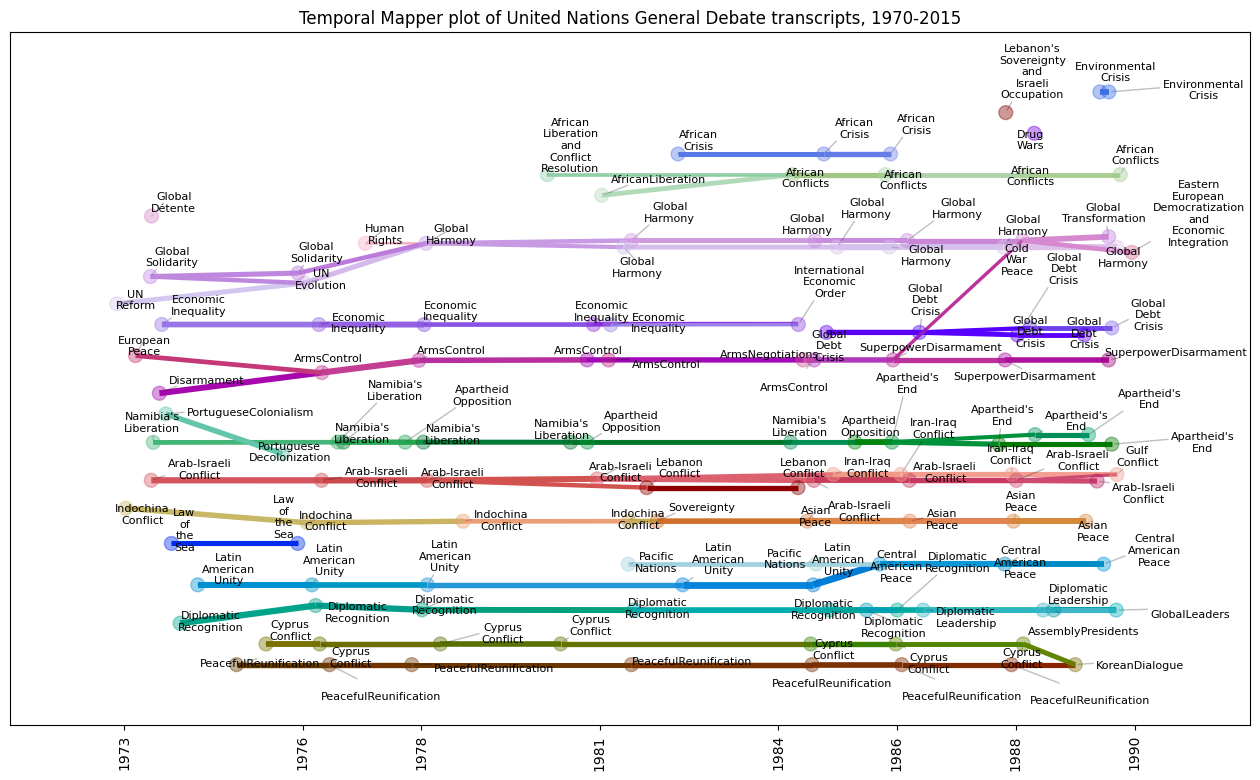

In [8]:
from temporalmapper.plotting import squarify_text


## Function to extract the cluster names from Toponymy
def make_labels(toponymy, layer, filter_dupes=False):
    topic_map = toponymy.clusterer.topic_map_[layer]
    cluster_labels = {}
    for node in toponymy.clusterer.mappers_[layer].graph.nodes():
        label =  toponymy.topic_names_[layer][topic_map[node]]
        if filter_dupes:
            G = toponymy.clusterer.mappers_[layer].graph
            if G.in_degree(node)==1 and G.out_degree(node)!=0:
                prev = [e for e in G.in_edges(node)][0][0]
                prev_label = toponymy.topic_names_[layer][topic_map[prev]]
                if prev_label == label:
                    label = ''
        cluster_labels[node]=squarify_text(label)
    return cluster_labels

## Plotting
fig, ax = plt.subplots(figsize=(16,9))

layer = 1
clusterer.mappers_[layer].temporal_plot(
    ax=ax,
    cluster_labels=make_labels(toponymy,layer),
    layout='ordered',
    cluster_label_kwargs=dict(fontsize=8),
    node_scaling=5,
    node_size_bounds=(25,100),
    node_size_scale='linear',
    edge_scaling=2,
    edge_weight_bounds=(5,25),
)

label_times = clusterer.mappers_[layer].midpoints
label_text = [int(label) for label in label_times]
ax.set_xticks(label_times, labels=label_text)
ax.tick_params(axis='x', labelrotation=90)
ax.tick_params(bottom=True, labelbottom=True)
ax.set_title("Temporal Mapper plot of United Nations General Debate transcripts, 1970-2015")
plt.show()

In [9]:
import plotly.io as pio
from plotly.graph_objects import Layout
pio.renderers.default = 'sphinx_gallery'

layer = 0
fig = clusterer.mappers_[layer].interactive_temporal_plot(
    cluster_labels=make_labels(toponymy,layer),
    layout='ordered',
    layout_kwargs=dict(spacing=10),
    graph_layout=Layout(
        title=dict(text="Temporal Mapper plot of United Nations General Debate transcripts, 1970-2015"),
        width=1200,
        height=700,
        showlegend=False,
    ),
    node_scaling=5,
    node_size_bounds=(25,100),
    node_size_scale='linear',
    edge_scaling=1,
    edge_weight_bounds=(1,5),
)
fig.show()